In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from matplotlib import rcParams

%matplotlib inline

# --- PLOT STYLING CONFIGURATION ---
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

from mpl_toolkits.mplot3d import Axes3D  

# --- 1. ENVIRONMENT CONFIGURATION (To prevent ROOT errors) ---
root_path = "/scratch/elena/root-6.26.04-install"
os.environ["ROOTSYS"] = root_path
os.environ["PYTHONPATH"] = f"{root_path}/lib:{os.environ.get('PYTHONPATH', '')}"
os.environ["LD_LIBRARY_PATH"] = f"{root_path}/lib:{os.environ.get('LD_LIBRARY_PATH', '')}"
sys.path.append(f"{root_path}/lib")

# Set variables so functions_bonsai can locate required files
os.environ["WCSIM_BUILD_DIR"] = "/scratch/elena/wcsim-install"
os.environ["BONSAIDIR"] = "/scratch/elena/bonsai"

# --- 2. CUSTOM SCRIPT IMPORTS ---
sys.path.append("/scratch/elena/9Li/scripts")
import functions_bonsai
import functions_multilateration

#Load data
multilat_folder = "/scratch/elena/9Li/results/run1848/multilat_output"
multilat_files = sorted(glob(f"{multilat_folder}/*_multilat_full.csv"))

print(f"Found {len(multilat_files)} high-quality files.")

if len(multilat_files) > 0:
    # 1. CARGAMOS EL MAPPING (Lo necesitas para tus funciones 3D)
    # Esto te permite convertir IDs de PMTs en coordenadas (x,y,z) del detector
    geo_data = functions_bonsai.get_geo_mapping()
    lookup = functions_bonsai.build_lookup_table(geo_data)

    # 2. CARGAMOS LOS DATOS RECONSTRUIDOS
    # Solo usamos converters si REALMENTE necesitas graficar cada hit individual en el 3D.
    # Si solo vas a graficar los VÉRTICES (x,y,z), cárgalo sin converters para que vuele.
    dfs = [pd.read_csv(f) for f in multilat_files]
    
    df_all = pd.concat(dfs, ignore_index=True)
    print(f"Total clusters loaded: {len(df_all)}")
    
    # 3. VERIFICACIÓN DE CALIDAD KARLEN
    if 'time_rms' in df_all.columns:
        rms_avg = df_all['time_rms'].mean()
        print(f"Average Time RMS of the sample: {rms_avg:.2f} ns")
else:
    print("ERROR: No files were found in the specified folder!")

Welcome to JupyROOT 6.26/04
Found 48 high-quality files.
Total clusters loaded: 661773
Average Time RMS of the sample: 4.63 ns


In [19]:
df_all.head()

,t_window_start_ns,t_window_start_rel_ns,nHits,spill_id,hit_card_ids,hit_slot_ids,hit_channel_ids,hit_position_ids,hit_times_ns,hit_charges,vertex_x,vertex_y,vertex_z,fit_success,n_hits_used,time_rms
0,6.539181e+12,4.217721e+08,39,160,"[93, 103, 103, 71, 98, 36, 73, 35, 35, 107, 10...","[101, 98, 98, 103, 100, 46, 31, 76, 76, 44, 44...","[13, 1, 4, 1, 4, 12, 16, 0, 1, 18, 13, 0, 17, ...","[12, 6, 1, 6, 1, 4, 14, 17, 6, 16, 12, 17, 15,...","[6539180839796.528, 6539180839796.403, 6539180...","[147.0, 80.0, 150.0, 49.0, 89.0, 197.0, 185.0,...",-23.020930,-28.872223,-83.007558,True,38,5.666497
1,6.539181e+12,4.220979e+08,39,160,"[89, 99, 99, 71, 71, 71, 36, 36, 23, 23, 23, 2...","[89, 90, 90, 103, 103, 103, 46, 46, 47, 47, 47...","[18, 16, 9, 4, 13, 16, 11, 12, 18, 1, 11, 4, 1...","[16, 14, 3, 1, 12, 14, 11, 4, 16, 6, 11, 1, 11...","[6539181165530.744, 6539181165527.439, 6539181...","[120.0, 104.0, 126.0, 139.0, 111.0, 237.0, 64....",-40.835997,14.364547,34.321215,True,39,5.236633
2,6.539182e+12,4.224943e+08,39,160,"[36, 16, 73, 26, 113, 113, 10, 35, 35, 35, 35,...","[46, 73, 31, 60, 26, 26, 61, 76, 76, 76, 76, 5...","[10, 18, 7, 11, 4, 13, 7, 1, 2, 9, 12, 11, 6, ...","[10, 16, 2, 11, 1, 12, 2, 6, 0, 3, 4, 11, 8, 1...","[6539181562009.38, 6539181562015.998, 65391815...","[101.0, 165.0, 187.0, 118.0, 173.0, 183.0, 175...",27.668587,73.863169,-95.292263,True,39,2.515019
3,6.539182e+12,4.225806e+08,30,160,"[103, 98, 98, 113, 113, 113, 47, 80, 115, 109,...","[98, 100, 100, 26, 26, 26, 13, 30, 57, 104, 53...","[6, 1, 13, 14, 2, 1, 8, 4, 4, 5, 16, 0, 16, 18...","[8, 6, 12, 13, 0, 6, 9, 1, 1, 7, 14, 17, 14, 1...","[6539181648257.196, 6539181648258.117, 6539181...","[221.0, 123.0, 252.0, 130.0, 124.0, 130.0, 92....",83.023959,-165.301351,-133.928929,True,30,4.036677
4,6.539182e+12,4.228657e+08,39,160,"[89, 89, 99, 99, 93, 103, 71, 36, 15, 15, 15, ...","[89, 89, 90, 90, 101, 98, 103, 46, 58, 58, 58,...","[14, 17, 3, 9, 3, 4, 10, 17, 1, 6, 3, 14, 9, 1...","[13, 15, 18, 3, 18, 1, 10, 15, 6, 8, 18, 13, 3...","[6539181933401.805, 6539181933399.609, 6539181...","[163.0, 280.0, 83.0, 60.0, 74.0, 115.0, 166.0,...",-33.745178,6.492705,11.903575,True,39,6.711087


In [2]:
import ast
import pandas as pd
from glob import glob

# Definir los conversores para que las columnas de listas se lean correctamente
convert_dict = {
    'hit_times_ns': ast.literal_eval, 
    'hit_slot_ids': ast.literal_eval, 
    'hit_channel_ids': ast.literal_eval
}

# Cargar los archivos directamente como listas
multilat_files = glob("/scratch/elena/9Li/results/run1848/multilat_output/*_multilat_full.csv")
df_all = pd.concat([pd.read_csv(f, converters=convert_dict) for f in multilat_files])

print(f"Total clusters loaded correctly: {len(df_all)}")

Total clusters loaded correctly: 661773


In [3]:
existing_mpmts = sorted(lookup.keys())
print(f"Min mPMT ID in lookup: {min(existing_mpmts)}")
print(f"Max mPMT ID in lookup: {max(existing_mpmts)}")
print(f"Total mPMTs in lookup: {len(existing_mpmts)}")

# Now check your data
all_data_mpmts = set()
for ids in df_all['hit_slot_ids'].iloc[:100]: # Check first 100 clusters
    all_data_mpmts.update(ids)

print(f"mPMT IDs found in your data: {sorted(list(all_data_mpmts))[:10]} ...")

Min mPMT ID in lookup: (0, 1)
Max mPMT ID in lookup: (105, 19)
Total mPMTs in lookup: 1843
mPMT IDs found in your data: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10] ...


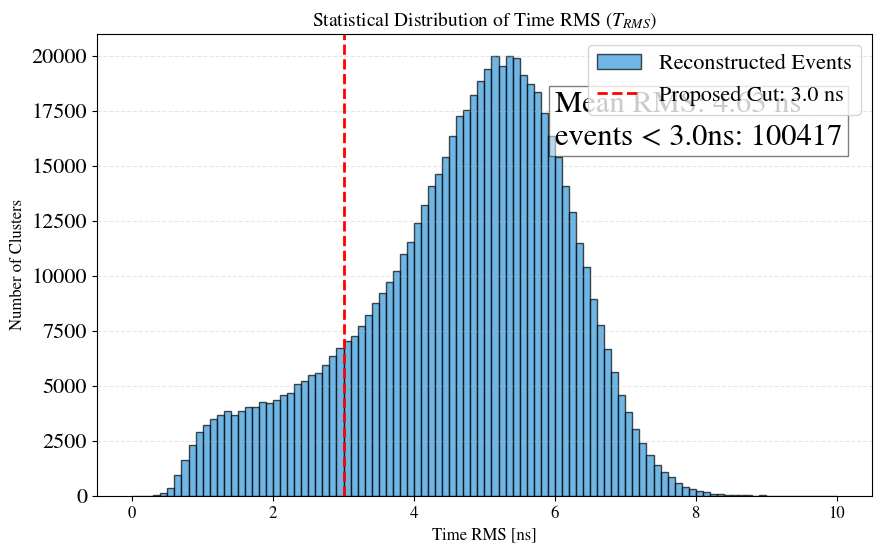

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. PREPARE DATA ---
# We only use events where the fit actually succeeded
rms_values = df_all[df_all['fit_success'] == True]['time_rms']

# --- 2. PLOT THE DISTRIBUTION ---
plt.figure(figsize=(10, 6))

# Histogram of RMS values
# We limit the range to 10 or 15 to see the 'peak' clearly
counts, bins, _ = plt.hist(rms_values, bins=100, range=[0, 10], 
                           color='#3498db', edgecolor='black', alpha=0.7, 
                           label='Reconstructed Events')

# --- 3. ANNOTATE THE CUT ---
# This is where you test your 3.0 ns or 2.5 ns threshold
current_cut = 3.0 
plt.axvline(current_cut, color='red', linestyle='--', linewidth=2, 
            label=f'Proposed Cut: {current_cut} ns')

# --- 4. FORMATTING ---
plt.title("Statistical Distribution of Time RMS ($T_{RMS}$)", fontsize=14)
plt.xlabel("Time RMS [ns]", fontsize=12)
plt.ylabel("Number of Clusters", fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend()

# Optional: Add a text box with statistics
mean_rms = np.mean(rms_values)
plt.text(6, max(counts)*0.8, f"Mean RMS: {mean_rms:.2f} ns\nevents < {current_cut}ns: {len(rms_values[rms_values < current_cut])}", 
         bbox=dict(facecolor='white', alpha=0.5))

plt.show()

In [24]:
# 1. Filter for successful fits and high quality (Karlen Cut)
# We use 3.0 ns as a standard 'clean' cut for this detector
df_success = df_all[df_all['fit_success'] == True].copy()
df_clean = df_success[df_success['time_rms'] < 2.2].copy()

print(f"Clusters with successful reconstruction: {len(df_success)}")
print(f"High-quality clusters (RMS < 3ns): {len(df_clean)}")

Clusters with successful reconstruction: 651850
High-quality clusters (RMS < 3ns): 55415


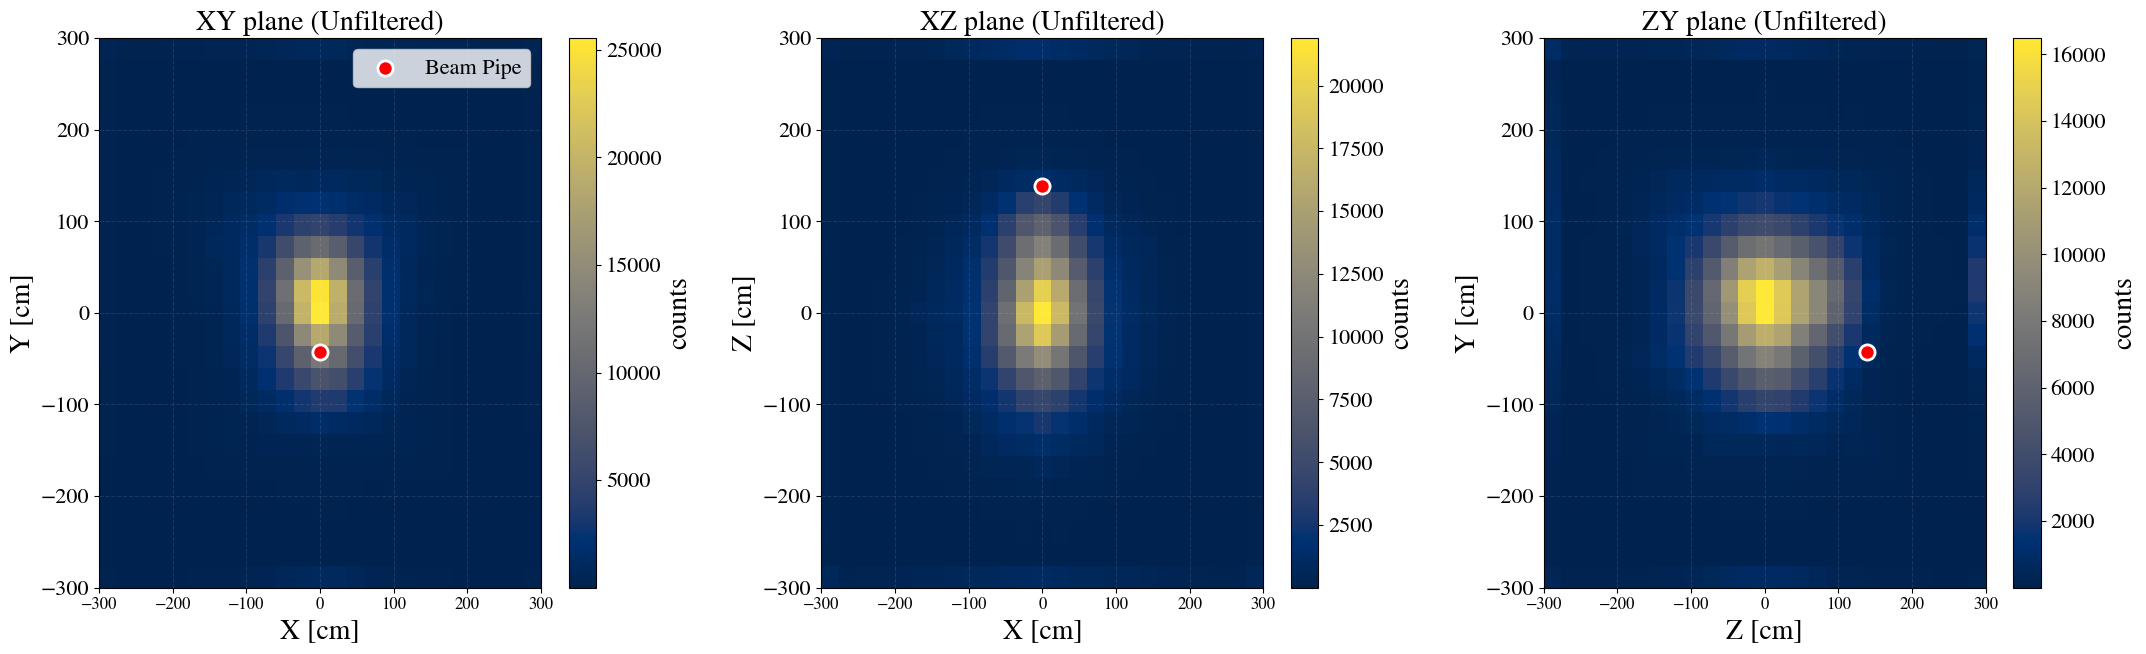

Total reconstructed clusters plotted: 651850


In [25]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DATA PREPARATION (RAW) ---
# We only filter for successful fits to ensure coordinates exist, 
# but we do NOT apply the Karlen Cut (RMS)
df_all_fits = df_all[df_all['fit_success'] == True].copy()

x_raw = df_all_fits["vertex_x"]
y_raw = df_all_fits["vertex_y"]
z_raw = df_all_fits["vertex_z"]

# --- 2. PLOT CONFIGURATION ---
fig, axs = plt.subplots(1, 3, figsize=(22, 7))

# Beam pipe target coordinates [x, y, z]
beam = np.array([0.0, -42.47, 138.79])

# Settings: Full volume view with 25 bins
BINS = 25 
LIMIT = 300 

# --- XY PLANE (FRONT VIEW) ---
h1 = axs[0].hist2d(x_raw, y_raw, bins=BINS, cmap="cividis", cmin=1, range=[[-LIMIT, LIMIT], [-LIMIT, LIMIT]])
axs[0].scatter(beam[0], beam[1], color="red", s=120, label="Beam Pipe", edgecolors="white", linewidth=2, zorder=10)
axs[0].set_title("XY plane (Unfiltered)")
axs[0].set_xlabel("X [cm]")
axs[0].set_ylabel("Y [cm]")
plt.colorbar(h1[3], ax=axs[0], label="counts")

# --- XZ PLANE (TOP VIEW) ---
h2 = axs[1].hist2d(x_raw, z_raw, bins=BINS, cmap="cividis", cmin=1, range=[[-LIMIT, LIMIT], [-LIMIT, LIMIT]])
axs[1].scatter(beam[0], beam[2], color="red", s=120, edgecolors="white", linewidth=2, zorder=10)
axs[1].set_title("XZ plane (Unfiltered)")
axs[1].set_xlabel("X [cm]")
axs[1].set_ylabel("Z [cm]")
plt.colorbar(h2[3], ax=axs[1], label="counts")

# --- ZY PLANE (SIDE VIEW) ---
h3 = axs[2].hist2d(z_raw, y_raw, bins=BINS, cmap="cividis", cmin=1, range=[[-LIMIT, LIMIT], [-LIMIT, LIMIT]])
axs[2].scatter(beam[2], beam[1], color="red", s=120, edgecolors="white", linewidth=2, zorder=10)
axs[2].set_title("ZY plane (Unfiltered)")
axs[2].set_xlabel("Z [cm]")
axs[2].set_ylabel("Y [cm]")
plt.colorbar(h3[3], ax=axs[2], label="counts")

# --- AESTHETICS ---
for ax in axs:
    ax.set_facecolor('#000033') 
    ax.grid(color='white', alpha=0.1, linestyle='--')

axs[0].legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"Total reconstructed clusters plotted: {len(df_all_fits)}")

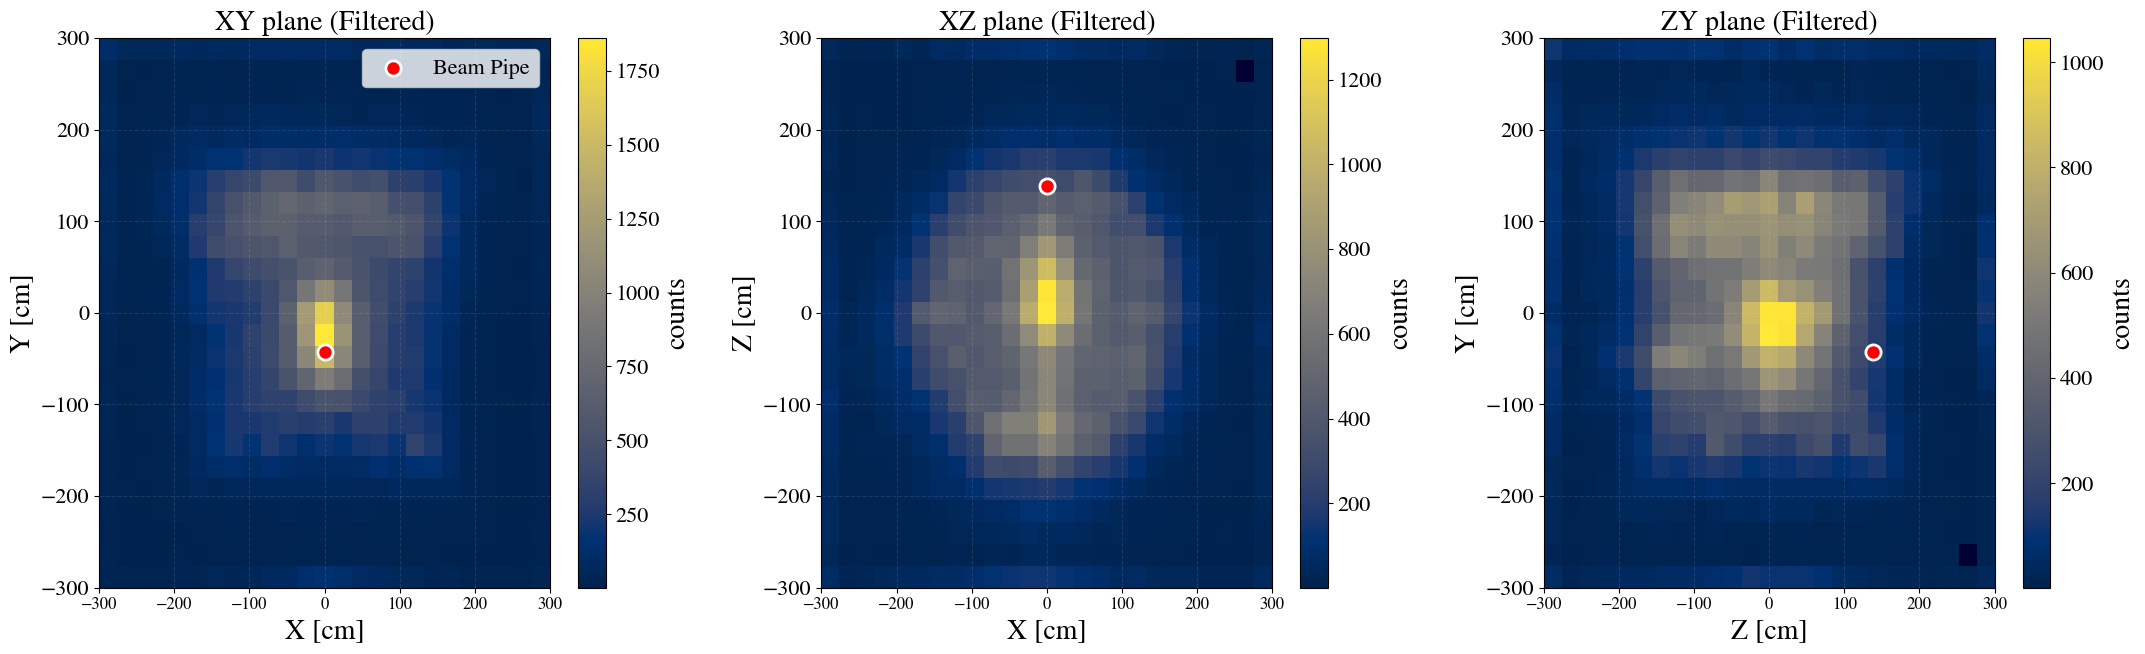

Total high-quality events plotted: 100417


In [26]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DATA PREPARATION (FILTERED) ---
# Filtering for success and the Karlen Cut (RMS < 3.0 ns)
karlen_cut = 3.0
df_clean = df_all[(df_all['fit_success'] == True) & (df_all['time_rms'] < karlen_cut)].copy()

x_f = df_clean["vertex_x"]
y_f = df_clean["vertex_y"]
z_f = df_clean["vertex_z"]

# --- 2. PLOT CONFIGURATION ---
fig, axs = plt.subplots(1, 3, figsize=(22, 7))

# Beam pipe target coordinates [x, y, z]
beam = np.array([0.0, -42.47, 138.79])

# Settings: Full volume view with 25 bins
BINS = 25 
LIMIT = 300 

# --- XY PLANE (FRONT VIEW) ---
h1 = axs[0].hist2d(x_f, y_f, bins=BINS, cmap="cividis", cmin=1, range=[[-LIMIT, LIMIT], [-LIMIT, LIMIT]])
axs[0].scatter(beam[0], beam[1], color="red", s=120, label="Beam Pipe", edgecolors="white", linewidth=2, zorder=10)
axs[0].set_title("XY plane (Filtered)")
axs[0].set_xlabel("X [cm]")
axs[0].set_ylabel("Y [cm]")
plt.colorbar(h1[3], ax=axs[0], label="counts")

# --- XZ PLANE (TOP VIEW) ---
h2 = axs[1].hist2d(x_f, z_f, bins=BINS, cmap="cividis", cmin=1, range=[[-LIMIT, LIMIT], [-LIMIT, LIMIT]])
axs[1].scatter(beam[0], beam[2], color="red", s=120, edgecolors="white", linewidth=2, zorder=10)
axs[1].set_title("XZ plane (Filtered)")
axs[1].set_xlabel("X [cm]")
axs[1].set_ylabel("Z [cm]")
plt.colorbar(h2[3], ax=axs[1], label="counts")

# --- ZY PLANE (SIDE VIEW) ---
# Corrected: Now strictly using z_f and y_f
h3 = axs[2].hist2d(z_f, y_f, bins=BINS, cmap="cividis", cmin=1, range=[[-LIMIT, LIMIT], [-LIMIT, LIMIT]])
axs[2].scatter(beam[2], beam[1], color="red", s=120, edgecolors="white", linewidth=2, zorder=10)
axs[2].set_title("ZY plane (Filtered)")
axs[2].set_xlabel("Z [cm]")
axs[2].set_ylabel("Y [cm]")
plt.colorbar(h3[3], ax=axs[2], label="counts")

# --- AESTHETICS ---
for ax in axs:
    ax.set_facecolor('#000033') 
    ax.grid(color='white', alpha=0.1, linestyle='--')

axs[0].legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"Total high-quality events plotted: {len(df_clean)}")

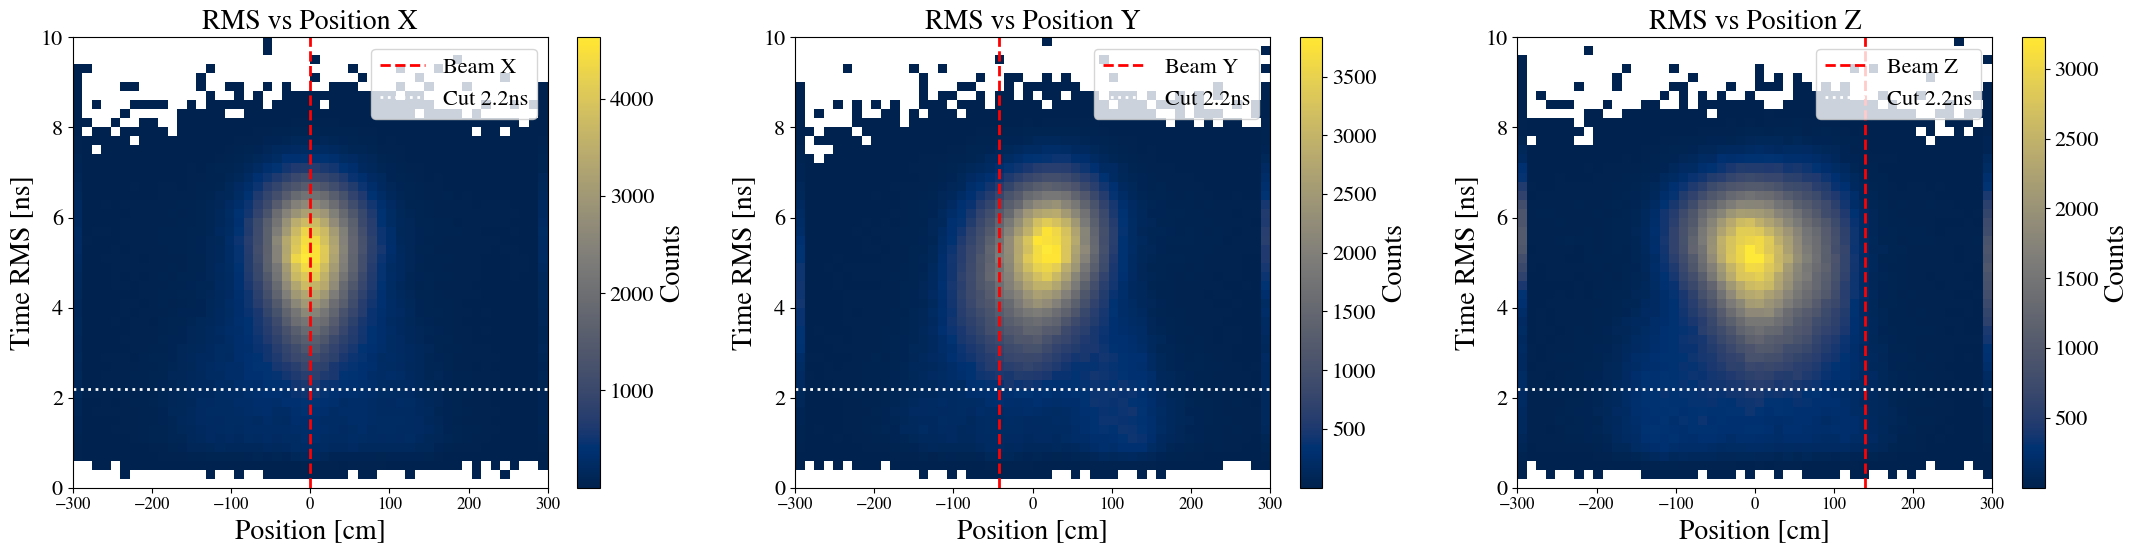

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DATA PREPARATION ---
df_diag = df_all[df_all['fit_success'] == True].copy()
beam = np.array([0.0, -42.47, 138.79])
OPTIMAL_CUT = 2.2

# --- 2. PLOT CONFIGURATION ---
fig, axs = plt.subplots(1, 3, figsize=(22, 6))
BINS = 50
RMS_LIMIT = 10 
POS_LIMIT = 300

# Subplot 1: RMS vs X
h1 = axs[0].hist2d(df_diag['vertex_x'], df_diag['time_rms'], bins=BINS, 
                   range=[[-POS_LIMIT, POS_LIMIT], [0, RMS_LIMIT]], cmap='cividis', cmin=1)
axs[0].axvline(beam[0], color='red', linestyle='--', linewidth=2, label='Beam X')
axs[0].set_title('RMS vs Position X')

# Subplot 2: RMS vs Y
h2 = axs[1].hist2d(df_diag['vertex_y'], df_diag['time_rms'], bins=BINS, 
                   range=[[-POS_LIMIT, POS_LIMIT], [0, RMS_LIMIT]], cmap='cividis', cmin=1)
axs[1].axvline(beam[1], color='red', linestyle='--', linewidth=2, label='Beam Y')
axs[1].set_title('RMS vs Position Y')

# Subplot 3: RMS vs Z
h3 = axs[2].hist2d(df_diag['vertex_z'], df_diag['time_rms'], bins=BINS, 
                   range=[[-POS_LIMIT, POS_LIMIT], [0, RMS_LIMIT]], cmap='cividis', cmin=1)
axs[2].axvline(beam[2], color='red', linestyle='--', linewidth=2, label='Beam Z')
axs[2].set_title('RMS vs Position Z')

# Aesthetics and Threshold marker
for i, ax in enumerate(axs):
    ax.axhline(OPTIMAL_CUT, color='white', linestyle=':', linewidth=2, label=f'Cut {OPTIMAL_CUT}ns')
    ax.set_xlabel('Position [cm]')
    ax.set_ylabel('Time RMS [ns]')
    ax.legend(loc='upper right')
    plt.colorbar([h1, h2, h3][i][3], ax=ax, label='Counts')

plt.tight_layout()
plt.show()

In [44]:
def test_cuts_3d(cut_list):
    # Beam pipe target coordinates
    beam_x, beam_y, beam_z = 0.0, -42.47, 138.79
    
    results = []
    print(f"{'Cut [ns]':<10} | {'Events':<8} | {'Err X [cm]':<12} | {'Err Y [cm]':<12} | {'Err Z [cm]':<12}")
    print("-" * 65)

    for c in cut_list:
        # Filter by success and RMS threshold
        subset = df_all[(df_all['fit_success'] == True) & (df_all['time_rms'] < c)]
        
        if len(subset) == 0:
            continue

        # Mean Absolute Error (MAE) for each axis
        err_x = np.mean(np.abs(subset['vertex_x'] - beam_x))
        err_y = np.mean(np.abs(subset['vertex_y'] - beam_y))
        err_z = np.mean(np.abs(subset['vertex_z'] - beam_z))
        
        results.append({
            'cut': c, 
            'n_events': len(subset), 
            'err_x': err_x, 
            'err_y': err_y, 
            'err_z': err_z
        })
        
        print(f"{c:<10} | {len(subset):<8} | {err_x:<12.2f} | {err_y:<12.2f} | {err_z:<12.2f}")
    
    return pd.DataFrame(results)

# Execute the test
cut_results = test_cuts_3d([3.5, 3.3, 3.0, 2.7, 2.5, 2.2, 2.0, 1.7, 1.5, 1.3, 1.0])

Cut [ns]   | Events   | Err X [cm]   | Err Y [cm]   | Err Z [cm]  
-----------------------------------------------------------------
3.5        | 139378   | 73.23        | 96.13        | 153.20      
3.3        | 122394   | 76.20        | 99.52        | 155.50      
3.0        | 100417   | 80.37        | 104.52       | 158.92      
2.7        | 81405    | 84.16        | 109.54       | 162.14      
2.5        | 70331    | 86.13        | 112.37       | 163.90      
2.2        | 55415    | 88.50        | 115.54       | 165.61      
2.0        | 46451    | 89.44        | 117.15       | 165.94      
1.7        | 33971    | 89.75        | 118.34       | 165.77      
1.5        | 26091    | 89.18        | 118.38       | 165.54      
1.3        | 18590    | 87.78        | 117.46       | 165.61      
1.0        | 8242     | 83.15        | 113.56       | 167.92      
